In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import CHECKPOINTS_DIR
from src.dataset import NoisyOfflineRLDataset
from src.encoder import DisentangledEncoder, PlainEncoder

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
These new versions include large bug fixes, new versions of Python, and are where all new development will continue. Please upgrade these libraries as soon as you're able to do so.
If you'd like to read more about the story behind this switch, please check out ]8;;https://farama.org/Announcing-Minari\this blog post]8;;\.
/home/wyuhan/miniconda3/envs/rl_env/lib/python3.8/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 2

In [2]:
# ── Experiment to visualise ──────────────────────────────────────────────────
ENV_NAME    = "halfcheetah-medium-v2"
NOISE_DIM   = 17          # noise_dim = true_state_dim → hardest proportional setting
NOISE_SCALE = 2.0
NOISE_TYPE  = "nonlinear"
SEED        = 1

# ── Latent dim (must match training) ─────────────────────────────────────────
# Formula from training notebooks: int(max(true_state_dim, NOISE_DIM) * 1.5)
# Computed after dataset load below.

# ── t-SNE settings ────────────────────────────────────────────────────────────
N_SAMPLES       = 2000    # subsample for speed; t-SNE is O(n^2)
TSNE_PERPLEXITY = 30
TSNE_SEED       = 42

# ── Colour feature ────────────────────────────────────────────────────────────
# HalfCheetah pure_obs index 9 = x-velocity (forward speed).
# Values are z-scored by the dataset; sign and rank are preserved.
COLOR_DIM = 9

# ── Methods to compare ────────────────────────────────────────────────────────
# Each entry: (method_name, display_label)
METHODS = [
    ("raw_noisy",            "Raw Noisy"),
    ("plain",                "Plain Encoder"),
    ("disentangled_hsic",    "HSIC"),
    ("disentangled_barlow",  "Barlow Twins"),
    ("disentangled_dcor",    "dCor"),
]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

# ── Output ────────────────────────────────────────────────────────────────────
SAVE = True
SAVE_DIR = PROJECT_ROOT / "results" / "tsne"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

device: cuda


In [3]:
# noisy_obs is already pre-normalised by the dataset constructor
# (clean-state portion is z-scored with obs_mean / obs_std).
dataset = NoisyOfflineRLDataset(
    env_name=ENV_NAME,
    noise_dim=NOISE_DIM,
    noise_scale=NOISE_SCALE,
    seed=SEED,
    use_timeouts=True,
    noise_type=NOISE_TYPE,
)

state_dim      = dataset.noisy_obs.shape[1]
action_dim     = dataset.actions.shape[1]
true_state_dim = dataset.obs_dim
LATENT_DIM     = int(max(true_state_dim, NOISE_DIM) * 1.5)

print(f"state_dim={state_dim}, true_state_dim={true_state_dim}, "
      f"action_dim={action_dim}, LATENT_DIM={LATENT_DIM}")

# Fixed subsample — same rows used for every method
rng      = np.random.default_rng(TSNE_SEED)
idx      = rng.choice(len(dataset), size=N_SAMPLES, replace=False)

noisy_np = dataset.noisy_obs[idx].numpy()    # [N, state_dim]  pre-normalised
pure_np  = dataset.pure_obs[idx].numpy()     # [N, true_state_dim]  same norm
color_v  = pure_np[:, COLOR_DIM]             # forward velocity

noisy_t  = torch.tensor(noisy_np, dtype=torch.float32).to(DEVICE)

print(f"Subsampled {N_SAMPLES} points. Color range: [{color_v.min():.2f}, {color_v.max():.2f}]")

/home/wyuhan/miniconda3/envs/rl_env/lib/python3.8/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
load datafile: 100%|██████████| 21/21 [00:01<00:00, 11.54it/s]


state_dim=34, true_state_dim=17, action_dim=6, LATENT_DIM=25
Subsampled 2000 points. Color range: [-3.49, 3.70]


In [4]:
def noise_tag(dim, scale, ntype):
    return f"nd{dim}_ns{str(scale).replace('.', 'p')}_{ntype}"

NOISE_TAG = noise_tag(NOISE_DIM, NOISE_SCALE, NOISE_TYPE)
CKPT_BASE = CHECKPOINTS_DIR

def _load_encoder(method: str) -> torch.nn.Module:
    ckpt_dir  = CKPT_BASE / method / ENV_NAME / NOISE_TAG / f"seed_{SEED}"
    ckpt_path = ckpt_dir / f"encoder_epoch_50.pth"
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    if method.startswith("disentangled"):
        enc = DisentangledEncoder(state_dim, action_dim, true_state_dim, LATENT_DIM)
    else:
        enc = PlainEncoder(state_dim, action_dim, true_state_dim, LATENT_DIM)

    enc.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    enc.eval().to(DEVICE)
    return enc


def get_latent(method: str) -> np.ndarray:
    """Return 2-D numpy array [N, d] of latent features for the subsampled rows."""
    if method == "raw_noisy":
        # No encoder: use the raw (pre-normalised) noisy observation directly.
        return noisy_np

    enc = _load_encoder(method)
    with torch.no_grad():
        # DisentangledEncoder returns (z_task, z_irrel); PlainEncoder returns (z, None).
        # We always visualise the task branch.
        z_task, _ = enc(noisy_t)
    return z_task.cpu().numpy()


latents = {}
for method, label in METHODS:
    print(f"  {label:20s}", end=" ")
    Z = get_latent(method)
    latents[method] = Z
    print(f"shape={Z.shape}")

  Raw Noisy            shape=(2000, 34)
  Plain Encoder        Auto-scaling Plain Encoder: State Dim=34 -> Hidden Dim=256


/tmp/ipykernel_252048/598905527.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  enc.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))


shape=(2000, 25)
  HSIC                 Auto-scaling Encoder: State Dim=34 -> Hidden Dim=256
shape=(2000, 25)
  Barlow Twins         Auto-scaling Encoder: State Dim=34 -> Hidden Dim=256
shape=(2000, 25)
  dCor                 Auto-scaling Encoder: State Dim=34 -> Hidden Dim=256
shape=(2000, 25)


In [5]:
embeddings = {}
for method, label in METHODS:
    print(f"t-SNE: {label} ...", end=" ", flush=True)
    Z_scaled = StandardScaler().fit_transform(latents[method])
    tsne = TSNE(
        n_components=2,
        perplexity=TSNE_PERPLEXITY,
        random_state=TSNE_SEED,
        n_iter=1000,
        init="pca",
        learning_rate="auto",
    )
    embeddings[method] = tsne.fit_transform(Z_scaled)
    print("done")

t-SNE: Raw Noisy ... done
t-SNE: Plain Encoder ... done
t-SNE: HSIC ... done
t-SNE: Barlow Twins ... done
t-SNE: dCor ... done


/tmp/ipykernel_252048/2445275255.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/tsne/tsne_halfcheetah-medium-v2_nd17_ns2p0_nonlinear_seed1.pdf


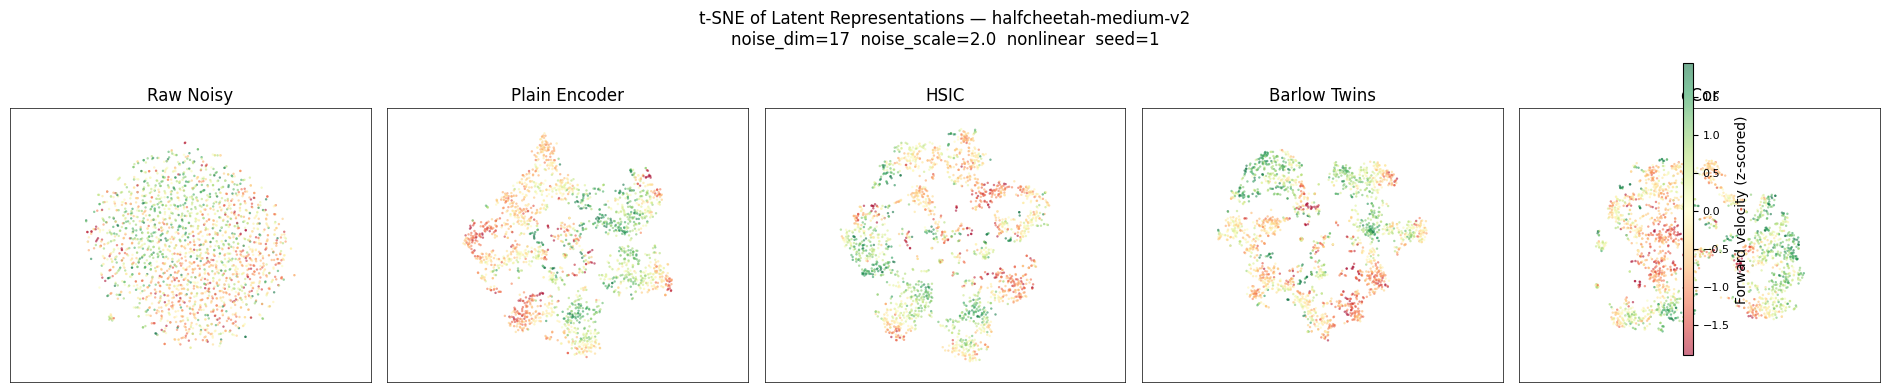

In [6]:
n = len(METHODS)
fig, axes = plt.subplots(1, n, figsize=(3.8 * n, 3.8))

# Shared colour scale across all panels
vmin, vmax = np.percentile(color_v, [2, 98])
norm  = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap  = "RdYlGn"

for ax, (method, label) in zip(axes, METHODS):
    emb = embeddings[method]
    sc = ax.scatter(
        emb[:, 0], emb[:, 1],
        c=color_v, cmap=cmap, norm=norm,
        s=3, alpha=0.55, linewidths=0, rasterized=True,
    )
    ax.set_title(label, fontsize=12, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect("equal", adjustable="datalim")
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

cbar = fig.colorbar(sc, ax=axes, fraction=0.015, pad=0.02, aspect=30)
cbar.set_label("Forward velocity (z-scored)", fontsize=10)
cbar.ax.tick_params(labelsize=8)

fig.suptitle(
    f"t-SNE of Latent Representations — {ENV_NAME}\n"
    f"noise_dim={NOISE_DIM}  noise_scale={NOISE_SCALE}  {NOISE_TYPE}  seed={SEED}",
    fontsize=12, y=1.02,
)
plt.tight_layout()

if SAVE:
    out = SAVE_DIR / f"tsne_{ENV_NAME}_{NOISE_TAG}_seed{SEED}.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=150)
    print(f"Saved: {out}")

plt.show()